In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')


df = pd.read_csv("hiring_duration_merged.csv", parse_dates=[
    "Submission Date", "Joining Date", "Sourcing Start", 
    "Interview Start", "Interview End", "Offered", "Filled"])

In [2]:
df.columns

Index(['Job Title', 'Job Location', 'Job Time Zone', 'Consultant Name', 'Visa',
       'Consultant Location', 'Consultant Time Zone', 'Salary ($1000)',
       'Relocation', 'Submission Date', 'Joining Date', 'Interview Status',
       'Hired', 'Sourcing Start', 'Interview Start', 'Interview End',
       'Offered', 'Filled'],
      dtype='object')

In [3]:
for column in df[['Job Title','Job Time Zone','Visa','Consultant Time Zone','Relocation', 'Interview Status', 'Hired']]:
    print(f"Column: {column}")
    print(f"Unique values: {df[column].unique()}")
    print(f"Number of unique values: {df[column].nunique()}")
    print("-" * 40)

Column: Job Title
Unique values: ['SAP' 'Big Data' 'DevOps Engineer' 'Java' 'Dot Net' 'ETL' 'Oracle EBS'
 'Project Manager' 'Workday Developer' 'UI Developer' 'Tester'
 'Salesforce' 'Test Lead' 'Sharepoint' 'Java Developer' 'Hadoop Developer'
 'Azure' 'Business Analyst' 'Big Data Developer' 'BI' 'Scrum Master' 'SQL'
 'Cloud Architect' 'Network Engineer' 'iOS Developer' 'Cloud Engineer'
 'ServiceNow' 'Python' 'Data Scientist' 'Hadoop developer'
 'Big Data Architect']
Number of unique values: 31
----------------------------------------
Column: Job Time Zone
Unique values: ['CST' 'PST' 'EST' 'MST']
Number of unique values: 4
----------------------------------------
Column: Visa
Unique values: ['H1B' 'US Citizen' 'Green Card' 'GC EAS' 'GC EAD' 'GC' 'H4 EAD' 'Citizen'
 'Green Card Holder']
Number of unique values: 9
----------------------------------------
Column: Consultant Time Zone
Unique values: ['EST' 'CST' 'PST' 'MST']
Number of unique values: 4
---------------------------------------

In [4]:
order=['Job Title', 'Job Location', 'Job Time Zone', 'Consultant Name', 'Visa',
       'Consultant Location', 'Consultant Time Zone', 'Salary ($1000)', 'Relocation',
       'Sourcing Start','Submission Date', 'Interview Start', 'Interview End',
       'Offered', 'Filled','Interview Status','Hired']
df = df[order]

In [5]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,$110K,Yes,2023-09-26 12:36:44,2023-09-29 12:36:44,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Y
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,$170K,No,2023-07-06 06:41:18,2023-07-08 06:41:18,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Y


In [6]:
# Strip whitespace from string fields
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# Fix salary format — convert "$110K" → 110000
df["Salary ($1000)"] = (
    df["Salary ($1000)"]
    .str.replace("$", "", regex=False)
    .str.replace("K", "", regex=False)
    .str.replace("k", "", regex=False)
    .astype(float) * 1000
)

In [7]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,110000.0,Yes,2023-09-26 12:36:44,2023-09-29 12:36:44,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Y
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,170000.0,No,2023-07-06 06:41:18,2023-07-08 06:41:18,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Y


In [8]:
# Standardize Yes/No flags
df["Relocation"] = df["Relocation"].str.title()
df["Hired"] = df["Hired"].replace({"Y": "Yes", "N": "No"})
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,110000.0,Yes,2023-09-26 12:36:44,2023-09-29 12:36:44,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Yes
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,170000.0,No,2023-07-06 06:41:18,2023-07-08 06:41:18,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Yes


In [9]:
# Convert Date Columns to Datetime
date_columns = [
    "Sourcing Start","Submission Date", 
    "Interview Start", "Interview End", "Offered", "Filled"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")  # done so that for example, these can be done: df['days_to_ship'] = (df['ship_date'] - df['order_date']).dt.days

In [10]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,110000.0,Yes,2023-09-26 12:36:44,2023-09-29 12:36:44,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Yes
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,170000.0,No,2023-07-06 06:41:18,2023-07-08 06:41:18,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Yes


In [11]:
# Interview duration (start → end)
df["Interview_Duration_Days"] = (
    df["Interview End"] - df["Interview Start"]
).dt.days

In [12]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired,Interview_Duration_Days
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,110000.0,Yes,2023-09-26 12:36:44,2023-09-29 12:36:44,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Yes,6
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,170000.0,No,2023-07-06 06:41:18,2023-07-08 06:41:18,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Yes,9


In [13]:
# Time from sourcing to offer
df["Days_Sourcing_to_Offer"] = (
    df["Offered"] - df["Sourcing Start"]
).dt.days

In [14]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired,Interview_Duration_Days,Days_Sourcing_to_Offer
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,110000.0,Yes,2023-09-26 12:36:44,2023-09-29 12:36:44,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Yes,6,16
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,170000.0,No,2023-07-06 06:41:18,2023-07-08 06:41:18,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Yes,9,19


In [15]:
job_summary = df.groupby("Job Title").agg({
    "Salary ($1000)": ["mean", "min", "max"],
    "Hired": lambda x: (x == "Yes").sum(),
    "Consultant Name": "count"
}).rename(columns={"Consultant Name": "Total Submitted"})
job_summary

Salary ($1000)                        Hired Total Submitted
                             mean       min       max <lambda>           count
Job Title                                                                     
Azure               150000.000000  150000.0  150000.0        1               1
BI                  111538.461538   85000.0  155000.0       17              26
Big Data            134027.777778  100000.0  185000.0       32              36
Big Data Architect  200000.000000  200000.0  200000.0        1               1
Big Data Developer  115000.000000  105000.0  125000.0        2               2
Business Analyst     97222.222222   80000.0  130000.0        6               9
Cloud Architect     160000.000000  160000.0  160000.0        1               1
Cloud Engineer      142083.333333   90000.0  185000.0       11              12
Data Scientist      132857.142857   80000.0  190000.0       14              14
DevOps Engineer     137222.222222  120000.0  180000.0        8               9
Dot Net             114705.882353   85000.0  175000.0       25              34
ETL                 115555.555556   85000.0  165000.0       20              27
Hadoop Developer    127500.000000  115000.0  150000.0        3               4
Hadoop developer    120000.000000  120000.0  120000.0        1               1
Java                100000.000000  100000.0  100000.0        1               1
Java Developer      116219.780220   80000.0  200000.0       70              91
Network Engineer    105909.090909   80000.0  150000.0       14              22
Oracle EBS          128333.333333   75000.0  180000.0       14              18
Project Manager     120500.000000  105000.0  135000.0       10              10
Python              129500.000000   95000.0  160000.0        9              10
SAP                 120000.000000  110000.0  145000.0        3               6
SQL                 120769.230769   95000.0  175000.0       11              13
Salesforce          136875.000000  100000.0  200000.0        8               8
Scrum Master        114444.444444   90000.0  140000.0        6               9
ServiceNow           85000.000000   85000.0   85000.0        0               1
Sharepoint          120000.000000  120000.0  120000.0        0               1
Test Lead           107500.000000  105000.0  110000.0        2               2
Tester              112750.000000   80000.0  175000.0       25              40
UI Developer        100526.315789   75000.0  140000.0       15              19
Workday Developer   129000.000000  100000.0  160000.0        4               5
iOS Developer       122500.000000   95000.0  185000.0        6               6

In [16]:
# Set Seaborn style
sns.set(style="whitegrid")

In [17]:
# # Salary Distribution by Job Title
# plt.figure(figsize=(10,6))
# sns.boxplot(data=df, x="Job Title", y="Salary ($1000)")
# plt.title("Salary Distribution by Job Title")
# plt.ylabel("Salary ($)")
# plt.xlabel("Job Title")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# # Hired vs Not Hired by Job Title
# plt.figure(figsize=(10,6))
# sns.countplot(data=df, x="Job Title", hue="Hired")
# plt.title("Hired vs Not Hired by Job Title")
# plt.ylabel("Count")
# plt.xlabel("Job Title")
# plt.xticks(rotation=45)
# plt.legend(title="Hired")
# plt.tight_layout()
# plt.show()
# # Relocation Requirement by Job Title
# plt.figure(figsize=(10,6))
# sns.countplot(data=df, x="Job Title", hue="Relocation")
# plt.title("Relocation Requirement by Job Title")
# plt.ylabel("Count")
# plt.xlabel("Job Title")
# plt.xticks(rotation=45)
# plt.legend(title="Relocation")
# plt.tight_layout()
# plt.show()

In [18]:
# # Average Salary per Job Title
# avg_salary = df.groupby("Job Title")["Salary ($1000)"].mean().sort_values(ascending=False)
# avg_salary

In [19]:
# df.head(2)

In [20]:

# plt.figure(figsize=(10,6))
# sns.barplot(x=avg_salary.index, y=avg_salary.values, palette="viridis")
# plt.title("Average Salary per Job Title")
# plt.ylabel("Average Salary ($)")
# plt.xlabel("Job Title")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

In [21]:
# df.head(2)

In [22]:
# Time-to-Fill Analysis
# Calculate time-to-fill in days
df['Time_to_Fill'] = (df['Filled'] - df['Sourcing Start']).dt.days

In [23]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired,Interview_Duration_Days,Days_Sourcing_to_Offer,Time_to_Fill
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,110000.0,Yes,2023-09-26 12:36:44,2023-09-29 12:36:44,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Yes,6,16,29
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,170000.0,No,2023-07-06 06:41:18,2023-07-08 06:41:18,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Yes,9,19,35


In [24]:
# plt.figure(figsize=(10,5))
# sns.boxplot(x='Job Title', y='Time_to_Fill', data=df)
# plt.title('Time-to-Fill by Job Title')
# plt.xticks(rotation=45)
# plt.show()

In [25]:
# # Salary Analysis
# # Remove $ and K from Salary column and convert to numeric
# df['Salary ($1000)'] = df['Salary ($1000)'].replace('[\$,K]', '', regex=True).astype(float)

In [26]:
# df.head(2)

In [27]:

# Average, min, max salary per job title
salary_stats = df.groupby('Job Title')['Salary ($1000)'].agg(['mean', 'min', 'max']).reset_index()
salary_stats

,Job Title,mean,min,max
0,Azure,150000.000000,150000.0,150000.0
1,BI,111538.461538,85000.0,155000.0
2,Big Data,134027.777778,100000.0,185000.0
3,Big Data Architect,200000.000000,200000.0,200000.0
4,Big Data Developer,115000.000000,105000.0,125000.0
5,Business Analyst,97222.222222,80000.0,130000.0
6,Cloud Architect,160000.000000,160000.0,160000.0
7,Cloud Engineer,142083.333333,90000.0,185000.0
8,Data Scientist,132857.142857,80000.0,190000.0
9,DevOps Engineer,137222.222222,120000.0,180000.0


In [28]:
# print("Salary Analysis per Job Title:")
# print(salary_stats)

In [29]:
df_hired = df[df['Hired'] == 'Yes']
# Visa Type Analysis
visa_counts = df_hired['Visa'].value_counts()
visa_counts

Visa
US Citizen           183
H1B                   64
GC                    48
H4 EAD                17
Green Card Holder     15
Citizen                8
Green Card             3
GC EAD                 1
GC EAS                 1
Name: count, dtype: int64

In [30]:
# plt.figure(figsize=(6,4))
# sns.barplot(x=visa_counts.index, y=visa_counts.values)
# plt.title('Number of Hires by Visa Type')
# plt.ylabel('Number of Hires')
# plt.show()

In [31]:
# Relocation Analysis
relocation_counts = df_hired['Relocation'].value_counts()
relocation_counts

Relocation
Yes           208
No             81
Local Only     38
Open           10
Name: count, dtype: int64

In [32]:
# plt.figure(figsize=(6,4))
# sns.barplot(x=relocation_counts.index, y=relocation_counts.values)
# plt.title('Number of Hires with Relocation')
# plt.ylabel('Number of Hires')
# plt.show()
# df.isnull().sum()

In [33]:

df = df.dropna(subset=['Job Time Zone', 'Consultant Time Zone','Relocation'])
df.isnull().sum()

Job Title                  0
Job Location               0
Job Time Zone              0
Consultant Name            0
Visa                       0
Consultant Location        0
Consultant Time Zone       0
Salary ($1000)             0
Relocation                 0
Sourcing Start             0
Submission Date            0
Interview Start            0
Interview End              0
Offered                    0
Filled                     0
Interview Status           0
Hired                      0
Interview_Duration_Days    0
Days_Sourcing_to_Offer     0
Time_to_Fill               0
dtype: int64

In [34]:
other_date_cols = ["Interview_Duration_Days","Days_Sourcing_to_Offer","Time_to_Fill"]
df = df.drop(columns=other_date_cols)
df
df.isnull().sum()

Job Title               0
Job Location            0
Job Time Zone           0
Consultant Name         0
Visa                    0
Consultant Location     0
Consultant Time Zone    0
Salary ($1000)          0
Relocation              0
Sourcing Start          0
Submission Date         0
Interview Start         0
Interview End           0
Offered                 0
Filled                  0
Interview Status        0
Hired                   0
dtype: int64

In [35]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,110000.0,Yes,2023-09-26 12:36:44,2023-09-29 12:36:44,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Yes
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,170000.0,No,2023-07-06 06:41:18,2023-07-08 06:41:18,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Yes


In [36]:
# # Ensure datetime dtype
# date_cols = ["Sourcing Start","Submission Date", "Interview Start", "Interview End", "Offered", "Filled"]
# df[date_cols] = df[date_cols].apply(pd.to_datetime)

In [37]:
# df["Dur_Sourcing_to_Submission"] = df["Submission Date"] - df["Sourcing Start"]
df["Dur_Sourcing_to_Submission"] = (df["Submission Date"] - df["Sourcing Start"]).dt.days
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired,Dur_Sourcing_to_Submission
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,110000.0,Yes,2023-09-26 12:36:44,2023-09-29 12:36:44,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Yes,3
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,170000.0,No,2023-07-06 06:41:18,2023-07-08 06:41:18,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Yes,2


In [38]:
other_date_cols2 = ["Dur_Sourcing_to_Submission"]
df = df.drop(columns=other_date_cols2)

In [39]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,110000.0,Yes,2023-09-26 12:36:44,2023-09-29 12:36:44,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Yes
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,170000.0,No,2023-07-06 06:41:18,2023-07-08 06:41:18,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Yes


In [40]:
# df["Dur_Submission_to_InterviewStart"] = df["Interview Start"] - df["Submission Date"]
# df["Dur_InterviewStart_to_InterviewEnd"] = df["Interview End"] - df["Interview Start"]
# df["Dur_InterviewEnd_to_Offered"] = df["Offered"] - df["Interview End"]
# df["Dur_Offered_to_Filled"] = df["Filled"] - df["Offered"]


df["Dur_Submission_to_InterviewStart"] = (df["Interview Start"] - df["Submission Date"]).dt.days
df["Dur_InterviewStart_to_InterviewEnd"] = (df["Interview End"] - df["Interview Start"]).dt.days
df["Dur_InterviewEnd_to_Offered"] = (df["Offered"] - df["Interview End"]).dt.days
df["Dur_Offered_to_Filled"] = (df["Filled"] - df["Offered"]).dt.days

In [41]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,...,Interview Start,Interview End,Offered,Filled,Interview Status,Hired,Dur_Submission_to_InterviewStart,Dur_InterviewStart_to_InterviewEnd,Dur_InterviewEnd_to_Offered,Dur_Offered_to_Filled
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,110000.0,Yes,2023-09-26 12:36:44,...,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Yes,4,6,3,13
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,170000.0,No,2023-07-06 06:41:18,...,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Yes,5,9,3,16


In [42]:
# categorical = ["Job Title","Job Location","Visa","Consultant Location",
#                "Job Time Zone","Consultant Time Zone","Relocation","Interview Status"]
# df = pd.get_dummies(df, columns=categorical)

In [43]:
# # Get all column names as a list
# all_columns = df.columns.tolist()
# print(all_columns)
# print(f"Total columns: {len(all_columns)}")

# # Or print with indices
# for i, col in enumerate(df.columns):
#     print(f"{i}: {col}")

In [44]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,...,Interview Start,Interview End,Offered,Filled,Interview Status,Hired,Dur_Submission_to_InterviewStart,Dur_InterviewStart_to_InterviewEnd,Dur_InterviewEnd_to_Offered,Dur_Offered_to_Filled
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,110000.0,Yes,2023-09-26 12:36:44,...,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Yes,4,6,3,13
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,170000.0,No,2023-07-06 06:41:18,...,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Yes,5,9,3,16


In [45]:
other_date_cols3 = ['Dur_Submission_to_InterviewStart',
       'Dur_InterviewStart_to_InterviewEnd', 'Dur_InterviewEnd_to_Offered',
       'Dur_Offered_to_Filled']
df = df.drop(columns=other_date_cols3)

In [46]:
df.head(2)

,Job Title,Job Location,Job Time Zone,Consultant Name,Visa,Consultant Location,Consultant Time Zone,Salary ($1000),Relocation,Sourcing Start,Submission Date,Interview Start,Interview End,Offered,Filled,Interview Status,Hired
0,SAP,"Austin, TX",CST,Asghar N. Siddiqui,H1B,"Bellmore, NY",EST,110000.0,Yes,2023-09-26 12:36:44,2023-09-29 12:36:44,2023-10-03 12:36:44,2023-10-09 12:36:44,2023-10-12 12:36:44,2023-10-25 12:36:44,Cleared,Yes
1,Big Data,"Dallas, TX",CST,Raman P Shanthirangam,US Citizen,"Coppell, Texas",CST,170000.0,No,2023-07-06 06:41:18,2023-07-08 06:41:18,2023-07-13 06:41:18,2023-07-22 06:41:18,2023-07-25 06:41:18,2023-08-10 06:41:18,Cleared,Yes


In [47]:
# df[['Sourcing Start', 'Submission Date', 'Interview Start', 'Interview End', 'Offered', 'Filled']].to_csv("hello.csv")

In [48]:
import pandas as pd
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


class StageTracker:
    def __init__(self, df):
        self.df = df.copy()
        self.stages = ['Sourcing Start', 'Submission Date', 'Interview Start', 
                       'Interview End', 'Offered', 'Filled']
        self.durations = ['Dur_Sourcing_to_Submission', 'Dur_Submission_to_InterviewStart', 
                          'Dur_InterviewStart_to_InterviewEnd', 'Dur_InterviewEnd_to_Offered', 'Dur_Offered_to_Filled']
        self.features = ['Sourcing_start_day', 'Sourcing_start_month']
        self.models = {}

    # --------------------------
    # Preprocessing
    # --------------------------
    def preprocess(self):
        for col in self.stages:
            self.df[col] = pd.to_datetime(self.df[col], errors='coerce')
            
        # Compute durations in days
        self.df['Dur_Sourcing_to_Submission'] = (self.df['Submission Date'] - self.df['Sourcing Start']).dt.total_seconds() / (3600*24)
        self.df['Dur_Submission_to_InterviewStart'] = (self.df['Interview Start'] - self.df['Submission Date']).dt.total_seconds() / (3600*24)
        self.df['Dur_InterviewStart_to_InterviewEnd'] = (self.df['Interview End'] - self.df['Interview Start']).dt.total_seconds() / (3600*24)
        self.df['Dur_InterviewEnd_to_Offered'] = (self.df['Offered'] - self.df['Interview End']).dt.total_seconds() / (3600*24)
        self.df['Dur_Offered_to_Filled'] = (self.df['Filled'] - self.df['Offered']).dt.total_seconds() / (3600*24)
        
        # Add simple features
        self.df['Sourcing_start_day'] = self.df['Sourcing Start'].dt.dayofweek
        self.df['Sourcing_start_month'] = self.df['Sourcing Start'].dt.month

    def printdf(self):
            print(self.df.head(2))
    # --------------------------
    # Train ML models for each stage
    # --------------------------
    def train_models(self):
        print("training happening")
        for dur in self.durations:
            valid_rows = self.df[self.df[dur].notna()]
            if len(valid_rows) == 0:
                continue
            X = valid_rows[self.features]
            print("X",X)
            y = valid_rows[dur]
            print("y",y)
            model = RandomForestRegressor(n_estimators=100, random_state=42)
            model.fit(X, y)
            self.models[dur] = model

    # --------------------------
    # Detect current stage
    # --------------------------
    def current_stage(self, record, current_time=None):
        if current_time is None:
            current_time = pd.Timestamp.now()
        last_stage = "Not Started"
        for stage in self.stages:
            ts = record.get(stage)
            if pd.isna(ts):
                break
            if pd.to_datetime(ts) <= current_time:
                last_stage = stage
            else:
                break
        return last_stage

    # --------------------------
    # Predict remaining stages
    # --------------------------
    def predict_remaining_stages(self, record, current_time=None):
        if current_time is None:
            current_time = pd.Timestamp.now()
        
        remaining_predictions = {}
        stage = self.current_stage(record, current_time)
        print("stage",stage)
        # Start prediction from last completed stage
        if stage == 'Filled':
            return remaining_predictions  # Nothing remaining
        
        start_index = self.stages.index(stage) + 1
        print("start_index",start_index)
        prev_stage = stage
        print("prev_stage",prev_stage)
        
        for i in range(start_index, len(self.stages)):
            next_stage = self.stages[i]
            # Map prev stage to duration
            stage_to_duration = {
                'Sourcing Start': 'Dur_Sourcing_to_Submission',
                'Submission Date': 'Dur_Submission_to_InterviewStart',
                'Interview Start': 'Dur_InterviewStart_to_InterviewEnd',
                'Interview End': 'Dur_InterviewEnd_to_Offered',
                'Offered': 'Dur_Offered_to_Filled'
            }
            
            model = self.models.get(stage_to_duration.get(prev_stage))
            if model is None:
                avg_duration = self.df[stage_to_duration.get(prev_stage)].mean()
                print("used average duration fallback")
            else:
                features_row = [[pd.to_datetime(record['Sourcing Start']).dayofweek,
                                 pd.to_datetime(record['Sourcing Start']).month]]
                avg_duration = model.predict(features_row)[0]
                print("used ML")
            
            prev_timestamp = record.get(prev_stage)
            if pd.isna(prev_timestamp):
                prev_timestamp = pd.Timestamp.now()
            
            predicted_timestamp = pd.to_datetime(prev_timestamp) + pd.Timedelta(days=avg_duration)
            remaining_predictions[next_stage] = predicted_timestamp
            prev_stage = next_stage  # update for next iteration
            record[prev_stage] = predicted_timestamp  # propagate predicted timestamp
        
        return remaining_predictions
    def evaluate_model_performance(self, test_size=0.2, random_state=42):
        """
        Evaluate model performance using train-test split
        """
        evaluation_results = {}
        
        for dur in self.durations:
            # Skip if no data
            valid_data = self.df[self.df[dur].notna()]
            if len(valid_data) < 10:  # Minimum data points
                continue
            
            # Train-test split
            from sklearn.model_selection import train_test_split
            X = valid_data[self.features]
            y = valid_data[dur]
            
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=random_state
            )
            
            # Train model
            model = RandomForestRegressor(n_estimators=100, random_state=42)
            model.fit(X_train, y_train)
            
            # Predictions
            y_pred = model.predict(X_test)
            
            # Calculate metrics
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
            
            evaluation_results[dur] = {
                'MAE_days': mae,
                'RMSE_days': rmse,
                'R2_score': r2,
                'MAPE_percent': mape,
                'samples_tested': len(y_test),
                'actual_mean_days': y_test.mean(),
                'predicted_mean_days': y_pred.mean()
            }
            
            # Store test predictions for analysis
            if not hasattr(self, 'test_predictions'):
                self.test_predictions = {}
            self.test_predictions[dur] = {
                'actual': y_test.values,
                'predicted': y_pred,
                'features': X_test.values
            }
        
        return evaluation_results
    
    def cross_validate_models(self, n_splits=5):
        """
        Perform cross-validation for more robust evaluation
        """
        from sklearn.model_selection import cross_val_score, KFold
        
        cv_results = {}
        
        for dur in self.durations:
            valid_data = self.df[self.df[dur].notna()]
            if len(valid_data) < n_splits * 2:  # Need enough data
                continue
            
            X = valid_data[self.features]
            y = valid_data[dur]
            
            model = RandomForestRegressor(n_estimators=100, random_state=42)
            
            # Cross-validation
            kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
            
            # Get multiple metrics
            mae_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
            rmse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
            r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
            
            cv_results[dur] = {
                'MAE_mean': -mae_scores.mean(),
                'MAE_std': mae_scores.std(),
                'RMSE_mean': -rmse_scores.mean(),
                'RMSE_std': rmse_scores.std(),
                'R2_mean': r2_scores.mean(),
                'R2_std': r2_scores.std()
            }
        
        return cv_results
    
    def evaluate_on_historical_candidates(self, sample_size=None):
        """
        Simulate predictions for historical candidates at various stages
        """
        results = []
        
        # Use sample if dataframe is large
        test_df = self.df if sample_size is None else self.df.sample(min(sample_size, len(self.df)))
        
        for idx, row in test_df.iterrows():
            # Simulate different current times (at each stage)
            for stage in self.stages:
                if pd.notna(row[stage]):
                    # Create record up to this stage
                    record = {}
                    for s in self.stages:
                        if self.stages.index(s) <= self.stages.index(stage):
                            record[s] = row[s]
                        else:
                            record[s] = pd.NaT
                    
                    # Predict remaining stages
                    current_time = pd.to_datetime(row[stage])
                    predictions = self.predict_remaining_stages(record, current_time)
                    
                    # Compare with actual values
                    for pred_stage, pred_date in predictions.items():
                        actual_date = row.get(pred_stage)
                        if pd.notna(actual_date):
                            error_days = (pred_date - pd.to_datetime(actual_date)).days
                            results.append({
                                'stage': pred_stage,
                                'error_days': error_days,
                                'actual_date': actual_date,
                                'predicted_date': pred_date,
                                'start_stage': stage
                            })
        
        return pd.DataFrame(results)
    
    def plot_error_distribution(self, evaluation_df):
        """
        Visualize prediction errors
        """
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, dur in enumerate(self.durations[:len(axes)]):
            if dur in self.test_predictions:
                actual = self.test_predictions[dur]['actual']
                predicted = self.test_predictions[dur]['predicted']
                errors = actual - predicted
                
                axes[idx].hist(errors, bins=20, edgecolor='black', alpha=0.7)
                axes[idx].axvline(x=0, color='r', linestyle='--', linewidth=2)
                axes[idx].set_title(f'{dur}\nMAE: {np.mean(np.abs(errors)):.1f} days')
                axes[idx].set_xlabel('Error (Actual - Predicted) days')
                axes[idx].set_ylabel('Frequency')
        
        plt.tight_layout()
        plt.show()


In [49]:
# # Ensure the features exist in the dataframe
# if 'Sourcing_start_day' not in df.columns:
#     df['Sourcing_start_day'] = pd.to_datetime(df['Sourcing Start']).dt.dayofweek
# if 'Sourcing_start_month' not in df.columns:
#     df['Sourcing_start_month'] = pd.to_datetime(df['Sourcing Start']).dt.month


In [50]:
# --------------------------
# Example usage
# --------------------------
tracker = StageTracker(df)

In [51]:
tracker.printdf()

  Job Title Job Location Job Time Zone        Consultant Name        Visa  \
0       SAP   Austin, TX           CST     Asghar N. Siddiqui         H1B   
1  Big Data   Dallas, TX           CST  Raman P Shanthirangam  US Citizen   

  Consultant Location Consultant Time Zone  Salary ($1000) Relocation  \
0        Bellmore, NY                  EST        110000.0        Yes   
1      Coppell, Texas                  CST        170000.0         No   

       Sourcing Start     Submission Date     Interview Start  \
0 2023-09-26 12:36:44 2023-09-29 12:36:44 2023-10-03 12:36:44   
1 2023-07-06 06:41:18 2023-07-08 06:41:18 2023-07-13 06:41:18   

        Interview End             Offered              Filled  \
0 2023-10-09 12:36:44 2023-10-12 12:36:44 2023-10-25 12:36:44   
1 2023-07-22 06:41:18 2023-07-25 06:41:18 2023-08-10 06:41:18   

  Interview Status Hired  
0          Cleared   Yes  
1          Cleared   Yes  


In [52]:
tracker.preprocess()

In [53]:
tracker.printdf()

  Job Title Job Location Job Time Zone        Consultant Name        Visa  \
0       SAP   Austin, TX           CST     Asghar N. Siddiqui         H1B   
1  Big Data   Dallas, TX           CST  Raman P Shanthirangam  US Citizen   

  Consultant Location Consultant Time Zone  Salary ($1000) Relocation  \
0        Bellmore, NY                  EST        110000.0        Yes   
1      Coppell, Texas                  CST        170000.0         No   

       Sourcing Start  ...              Filled Interview Status Hired  \
0 2023-09-26 12:36:44  ... 2023-10-25 12:36:44          Cleared   Yes   
1 2023-07-06 06:41:18  ... 2023-08-10 06:41:18          Cleared   Yes   

  Dur_Sourcing_to_Submission Dur_Submission_to_InterviewStart  \
0                        3.0                              4.0   
1                        2.0                              5.0   

  Dur_InterviewStart_to_InterviewEnd Dur_InterviewEnd_to_Offered  \
0                                6.0                         3.0

In [54]:
tracker.train_models()

training happening
X      Sourcing_start_day  Sourcing_start_month
0                     1                     9
1                     3                     7
2                     2                     9
3                     1                    11
4                     5                     9
..                  ...                   ...
434                   4                     8
435                   4                    11
436                   2                     8
437                   1                     1
438                   6                     8

[436 rows x 2 columns]
y 0      3.0
1      2.0
2      3.0
3      4.0
4      2.0
      ... 
434    4.0
435    3.0
436    4.0
437    1.0
438    1.0
Name: Dur_Sourcing_to_Submission, Length: 436, dtype: float64
X      Sourcing_start_day  Sourcing_start_month
0                     1                     9
1                     3                     7
2                     2                     9
3                     1         

In [55]:

# New ongoing record
new_record = {
    'Sourcing Start': '2023-12-20 10:00:00',
    'Submission Date': '2023-12-23 10:00:00',
    'Interview Start': pd.NaT,
    'Interview End': pd.NaT,
    'Offered': pd.NaT,
    'Filled': pd.NaT
}

full_timeline = tracker.predict_remaining_stages(new_record)
print("Predicted future stages and timestamps:")
for stage, ts in full_timeline.items():
    print(f"{stage}: {ts}")


stage Submission Date
start_index 2
prev_stage Submission Date
used ML
used ML
used ML
used ML
Predicted future stages and timestamps:
Interview Start: 2023-12-26 15:41:44.914285714
Interview End: 2024-01-01 07:54:20.571428571
Offered: 2024-01-05 05:07:42.171428571
Filled: 2024-01-22 05:14:13.028571428


In [56]:

# 1. Basic model performance
print("=== Model Performance Evaluation ===")
performance = tracker.evaluate_model_performance()
for dur, metrics in performance.items():
    print(f"\n{dur}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.2f}")

=== Model Performance Evaluation ===

Dur_Sourcing_to_Submission:
  MAE_days: 0.85
  RMSE_days: 1.11
  R2_score: -0.35
  MAPE_percent: 34.23
  samples_tested: 88.00
  actual_mean_days: 2.78
  predicted_mean_days: 2.47

Dur_Submission_to_InterviewStart:
  MAE_days: 1.73
  RMSE_days: 2.23
  R2_score: -0.37
  MAPE_percent: 51.07
  samples_tested: 88.00
  actual_mean_days: 4.59
  predicted_mean_days: 4.48

Dur_InterviewStart_to_InterviewEnd:
  MAE_days: 2.05
  RMSE_days: 2.50
  R2_score: -0.62
  MAPE_percent: 39.15
  samples_tested: 88.00
  actual_mean_days: 6.77
  predicted_mean_days: 6.60

Dur_InterviewEnd_to_Offered:
  MAE_days: 0.91
  RMSE_days: 1.14
  R2_score: -0.10
  MAPE_percent: 29.60
  samples_tested: 88.00
  actual_mean_days: 3.68
  predicted_mean_days: 3.59

Dur_Offered_to_Filled:
  MAE_days: 2.26
  RMSE_days: 2.84
  R2_score: -0.24
  MAPE_percent: 17.60
  samples_tested: 88.00
  actual_mean_days: 13.73
  predicted_mean_days: 13.24


In [57]:
# 2. Cross-validation results
print("\n=== Cross-Validation Results ===")
cv_results = tracker.cross_validate_models()
for dur, metrics in cv_results.items():
    print(f"\n{dur}:")
    print(f"  MAE: {metrics['MAE_mean']:.1f} ± {metrics['MAE_std']:.1f} days")
    print(f"  RMSE: {metrics['RMSE_mean']:.1f} ± {metrics['RMSE_std']:.1f} days")
    print(f"  R²: {metrics['R2_mean']:.3f} ± {metrics['R2_std']:.3f}")


=== Cross-Validation Results ===

Dur_Sourcing_to_Submission:
  MAE: 0.9 ± 0.1 days
  RMSE: 1.1 ± 0.1 days
  R²: -0.273 ± 0.091

Dur_Submission_to_InterviewStart:
  MAE: 1.7 ± 0.1 days
  RMSE: 2.2 ± 0.1 days
  R²: -0.224 ± 0.117

Dur_InterviewStart_to_InterviewEnd:
  MAE: 1.9 ± 0.1 days
  RMSE: 2.3 ± 0.1 days
  R²: -0.300 ± 0.213

Dur_InterviewEnd_to_Offered:
  MAE: 0.9 ± 0.0 days
  RMSE: 1.1 ± 0.1 days
  R²: -0.245 ± 0.090

Dur_Offered_to_Filled:
  MAE: 2.5 ± 0.2 days
  RMSE: 3.1 ± 0.2 days
  R²: -0.147 ± 0.109


In [58]:
# 3. Historical simulation
print("\n=== Historical Simulation Results ===")
historical_results = tracker.evaluate_on_historical_candidates(sample_size=100)

if len(historical_results) > 0:
    print(f"Total predictions evaluated: {len(historical_results)}")
    
    # Summary statistics by stage
    stage_summary = historical_results.groupby('stage').agg({
        'error_days': ['mean', 'std', 'count', lambda x: np.mean(np.abs(x))]
    }).round(1)
    
    stage_summary.columns = ['mean_error', 'std_error', 'count', 'MAE']
    print("\nError statistics by stage:")
    print(stage_summary)
    
    # Overall statistics
    overall_mae = historical_results['error_days'].abs().mean()
    overall_std = historical_results['error_days'].std()
    accuracy_within_7_days = (historical_results['error_days'].abs() <= 7).mean() * 100
    
    print(f"\nOverall MAE: {overall_mae:.1f} days")
    print(f"Overall Std: {overall_std:.1f} days")
    print(f"Accuracy within 7 days: {accuracy_within_7_days:.1f}%")


=== Historical Simulation Results ===
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
used ML
u

KeyboardInterrupt: 

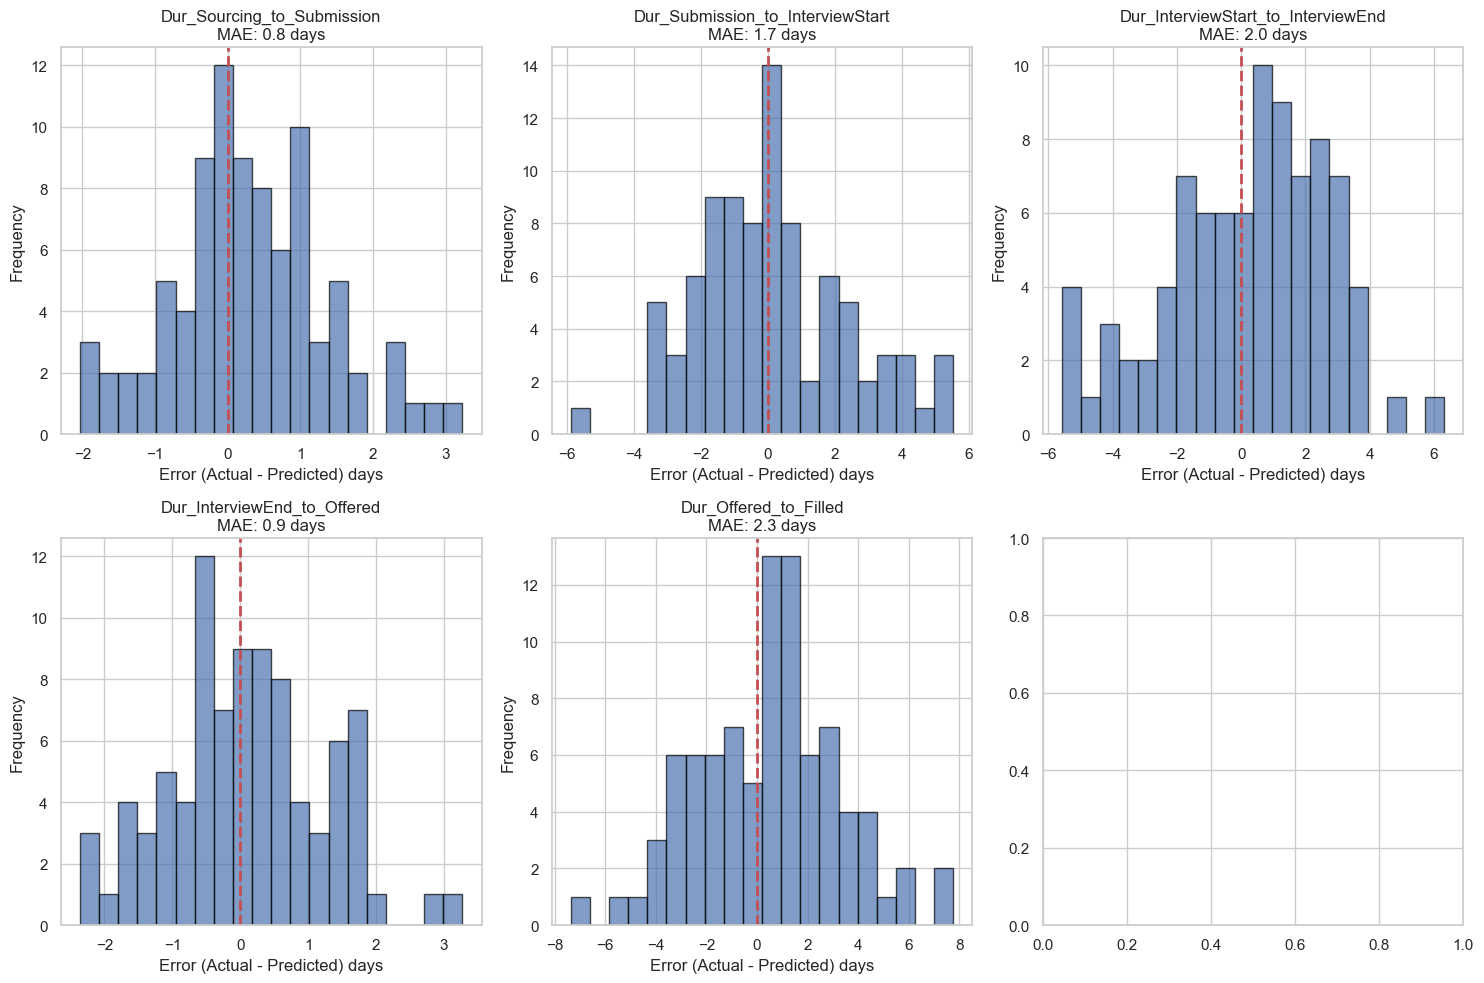

In [ ]:

# 4. Visualize errors
if hasattr(tracker, 'test_predictions'):
    tracker.plot_error_distribution(historical_results)

In [ ]:
# 5. Compare with baseline (simple average)
print("\n=== Comparison with Baseline (Simple Average) ===")
for dur in tracker.durations:
    if dur in tracker.df.columns:
        actual_values = tracker.df[dur].dropna()
        if len(actual_values) > 0:
            mean_value = actual_values.mean()
            mae_baseline = np.mean(np.abs(actual_values - mean_value))
            print(f"{dur}:")
            print(f"  Baseline MAE (using mean): {mae_baseline:.1f} days")
            if dur in performance:
                improvement = ((mae_baseline - performance[dur]['MAE_days']) / mae_baseline) * 100
                print(f"  Model improvement: {improvement:.1f}% better")


=== Comparison with Baseline (Simple Average) ===
Dur_Sourcing_to_Submission:
  Baseline MAE (using mean): 0.8 days
  Model improvement: -3.5% better
Dur_Submission_to_InterviewStart:
  Baseline MAE (using mean): 1.6 days
  Model improvement: -7.6% better
Dur_InterviewStart_to_InterviewEnd:
  Baseline MAE (using mean): 1.6 days
  Model improvement: -26.1% better
Dur_InterviewEnd_to_Offered:
  Baseline MAE (using mean): 0.9 days
  Model improvement: -5.9% better
Dur_Offered_to_Filled:
  Baseline MAE (using mean): 2.3 days
  Model improvement: 2.1% better


In [ ]:
tracker.models.keys()

dict_keys(['Dur_Sourcing_to_Submission', 'Dur_Submission_to_InterviewStart', 'Dur_InterviewStart_to_InterviewEnd', 'Dur_InterviewEnd_to_Offered', 'Dur_Offered_to_Filled'])

In [ ]:

# # New ongoing record
# new_record = {
#     'Sourcing Start': '2023-12-20 10:00:00',
#     'Submission Date': pd.NaT,
#     'Interview Start': pd.NaT,
#     'Interview End': pd.NaT,
#     'Offered': pd.NaT,
#     'Filled': pd.NaT
# }

# full_timeline = tracker.predict_remaining_stages(new_record)
# print("Predicted future stages and timestamps:")
# for stage, ts in full_timeline.items():
#     print(f"{stage}: {ts}")


In [ ]:
# # Get all column names as a list
# all_columns = df.columns.tolist()
# print(all_columns)
# print(f"Total columns: {len(all_columns)}")

# # Or print with indices
# for i, col in enumerate(df.columns):
#     print(f"{i}: {col}")